In [11]:
# Laboratorio 7 — Teoría de Probabilidades
## Simulación Monte Carlo del Álbum Panini

# Introducción

En este laboratorio se estudia el problema clásico del coleccionista de cupones (*coupon collector problem*) aplicado al álbum Panini.

Se utilizarán simulaciones Monte Carlo para estimar:

- el número esperado de sobres necesarios,
- el número esperado de estampas repetidas,
- la probabilidad de completar el álbum con una cantidad fija de sobres.

La teoría establece que el número esperado de sobres necesarios es:

$$
E[T] \approx \frac{N}{S} H_N
$$

donde:

$$
H_N = \sum_{k=1}^{N}\frac{1}{k}
$$
y:

- \(N\) = número total de estampas,
- \(S\) = estampas distintas por sobre,
- \(H_N\) = número armónico.

# ETAPA 1 — Simulación básica con álbum reducido

## Objetivo

Simular el proceso de llenado de un álbum de estampas utilizando un número reducido de estampas para comparar los resultados empíricos con la teoría del coleccionista.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N = 100
S = 7
R = 10000

# Semilla
np.random.seed(2026)

# Simulación del llenado del álbum

In [31]:
# Arreglos para almacenar resultados
sobres_totales = []
repetidas_totales = []

# Simulación
for _ in range(R):

    # álbum vacío
    album = np.zeros(N, dtype=bool)

    sobres = 0
    repetidas = 0
    distintas = 0

    # continuar hasta completar álbum
    while distintas < N:

        # generar un sobre
        sobre = np.random.choice(
            N,
            size=S,
            replace=False
        )

        sobres += 1

        # revisar estampas del sobre
        for estampa in sobre:

            if album[estampa]:
                repetidas += 1
            else:
                album[estampa] = True
                distintas += 1

    sobres_totales.append(sobres)
    repetidas_totales.append(repetidas)

# Convertir a numpy
sobres_totales = np.array(sobres_totales)
repetidas_totales = np.array(repetidas_totales)

# Estadísticas principales

In [17]:
# Estadísticas
media_sobres = np.mean(sobres_totales)
std_sobres = np.std(sobres_totales)

media_repetidas = np.mean(repetidas_totales)
std_repetidas = np.std(repetidas_totales)

prob_mas_30 = np.mean(sobres_totales > 30)

print("================================================")
print("RESULTADOS ETAPA 1")
print("================================================\n")

print(f"Media de sobres: {media_sobres:.4f}")
print(f"Desviación estándar sobres: {std_sobres:.4f}\n")

print(f"Media de repetidas: {media_repetidas:.4f}")
print(f"Desviación estándar repetidas: {std_repetidas:.4f}\n")

print(f"P(T > 30): {prob_mas_30:.4f}")

RESULTADOS ETAPA 1

Media de sobres: 72.2456
Desviación estándar sobres: 17.4715

Media de repetidas: 405.7192
Desviación estándar repetidas: 122.3006

P(T > 30): 1.0000


# Cálculo del mínimo teórico

El mínimo número posible de sobres es:

$$
\left\lceil \frac{N}{S} \right\rceil
$$
porque cada sobre contiene únicamente 7 estampas distintas.

In [18]:
minimo_teorico = np.ceil(N / S)

print(f"Mínimo teórico de sobres: {minimo_teorico}")

Mínimo teórico de sobres: 15.0


# Cálculo teórico usando el problema del coleccionista

La teoría establece:

$$
E[T] \approx \frac{N}{S} H_N
$$

donde:

$$
H_N = \sum_{k=1}^{N}\frac{1}{k}
$$

In [19]:
# Número armónico
H_N = np.sum(1 / np.arange(1, N + 1))

print(f"H_{N} = {H_N:.6f}")

H_100 = 5.187378


In [20]:
# Valor esperado teórico
E_teorico = (N / S) * H_N

print(f"Valor esperado teórico: {E_teorico:.4f}")

Valor esperado teórico: 74.1054


# Histograma del número de sobres

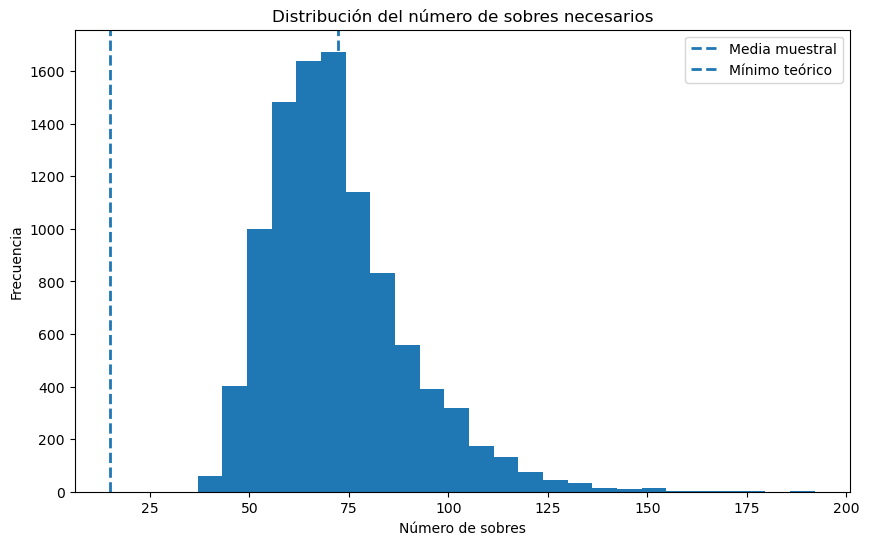

In [22]:
plt.figure(figsize=(10,6))

plt.hist(
    sobres_totales,
    bins=25
)

plt.axvline(
    media_sobres,
    linestyle='--',
    linewidth=2,
    label='Media muestral'
)

plt.axvline(
    minimo_teorico,
    linestyle='--',
    linewidth=2,
    label='Mínimo teórico'
)

plt.xlabel("Número de sobres")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de sobres necesarios")

plt.legend()

plt.show()

# Preguntas de análisis

## 1. ¿Cuál es el número mínimo de sobres?

El mínimo teórico es:

$$
\left\lceil \frac{100}{7} \right\rceil = 15
$$

porque:

- 14 sobres permiten obtener como máximo 98 estampas,
- 15 sobres permiten obtener hasta 105 estampas.

Sí puede ocurrir en simulaciones, pero es extremadamente raro debido a las estampas repetidas.

## 2. Comparación con la teoría del coleccionista

La teoría establece:

$$
E[T] \approx \frac{N}{S} H_N
$$

Para \(N = 100\):

$$
H_{100} \approx 5.187378
$$

Entonces:

$$
E[T] \approx \frac{100}{7}(5.187378)
$$

$$
E[T] \approx 74
$$

La media simulada debería ser cercana a este valor.

## 3. Número esperado de estampas repetidas

Si se necesitan aproximadamente 74 sobres:

$$
74 \times 7 = 518
$$

estampas totales obtenidas.

Como únicamente 100 son distintas:

$$
518 - 100 = 418
$$

aproximadamente 418 serían repetidas.

## 4. Interpretación de la desviación estándar

La desviación estándar suele ser relativamente grande porque:

- al inicio es muy fácil obtener estampas nuevas,
- al final faltan muy pocas estampas,
- conseguir las últimas puede requerir muchos sobres adicionales.

Esto genera alta variabilidad en el proceso.

# ETAPA 2 — Probabilidad de completar el álbum

## Objetivo

Estimar la probabilidad de completar el álbum después de comprar exactamente \(M\) sobres.

In [23]:
M_values = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

# Simulación de probabilidades

In [24]:
probabilidades = []

for M in M_values:

    exitos = 0

    for _ in range(R):

        album = np.zeros(N, dtype=bool)

        for _ in range(M):

            sobre = np.random.choice(
                N,
                size=S,
                replace=False
            )

            album[sobre] = True

        if np.all(album):
            exitos += 1

    prob = exitos / R

    probabilidades.append(prob)

    print(f"M = {M:2d} --> P(completar) = {prob:.4f}")

M = 20 --> P(completar) = 0.0000
M = 25 --> P(completar) = 0.0000
M = 30 --> P(completar) = 0.0000
M = 35 --> P(completar) = 0.0000
M = 40 --> P(completar) = 0.0023
M = 45 --> P(completar) = 0.0152
M = 50 --> P(completar) = 0.0587
M = 60 --> P(completar) = 0.2692
M = 70 --> P(completar) = 0.5198
M = 80 --> P(completar) = 0.7403


# Gráfica de probabilidades

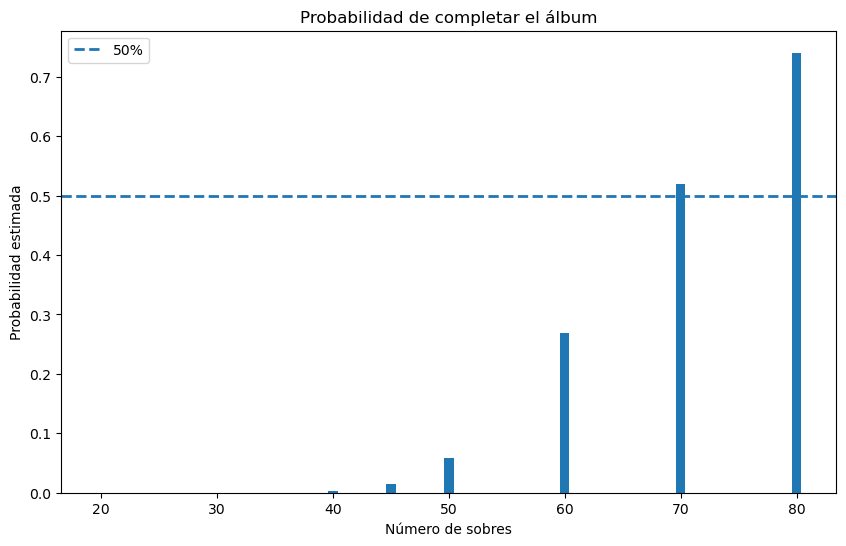

In [28]:
plt.figure(figsize=(10,6))

plt.bar(
    M_values,
    probabilidades
)

plt.axhline(
    0.5,
    linestyle='--',
    linewidth=2,
    label='50%'
)

plt.xlabel("Número de sobres")
plt.ylabel("Probabilidad estimada")
plt.title("Probabilidad de completar el álbum")

plt.legend()

plt.show()

# Análisis de probabilidades

In [27]:
for M, p in zip(M_values, probabilidades):

    if p >= 0.5:
        print(f"Primera vez que supera 50%: M = {M}")
        break

for M, p in zip(M_values, probabilidades):

    if p >= 0.9:
        print(f"Primera vez que supera 90%: M = {M}")
        break

Primera vez que supera 50%: M = 70


# Cota superior usando unión de eventos

La teoría establece que:

$$
P(\text{una estampa específica no aparece})
\approx
e^{-MS/N}
$$

Usando unión de eventos:

$$
P(\text{falta al menos una})
\leq
N e^{-MS/N}
$$

In [29]:
M = 50

cota = N * np.exp(-(M * S) / N)

print(f"Cota superior: {cota:.6f}")

Cota superior: 3.019738


# Interpretación de la cota

Si la cota resulta mayor que 1:

- no es útil como probabilidad,
- aunque sigue siendo matemáticamente válida como cota superior.

Esto muestra que la desigualdad de unión puede ser muy conservadora en este problema.